# Collective States via HMM — Updated Overlap Labels

**Objective:** Reproduce HMM analysis (5 states) with updated transcript overlap data.

**Key Change:** `tr_competitive_overlap` now includes 52 previously `needs_review` entries.

**Method:** Gaussian HMM + BIC selection (k=2-6) on 10 diagnostic-cleaned features.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.stats import multivariate_normal
from scipy.special import logsumexp
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
%matplotlib inline

print("✓ Imports loaded")

✓ Imports loaded


## 1. Load & Preprocess Data

In [11]:
# Load FULL updated feature matrix (all 10 groups)
windows = pd.read_csv('../_tmp_collective_fullsample_export/features/collective_window_features.tsv', sep='\t')
print(f'✓ Loaded {len(windows)} windows, {windows["group_id"].nunique()} groups')

# Filter to T1-T3 with transcript data
data = windows[windows['task_id'].isin(['T1','T2','T3'])].copy()
data = data.dropna(subset=['tr_spk_duration_s'])
print(f'✓ Filtered to {len(data)} transcript-covered windows (T1-T3)')
print(f'  Groups: {sorted(data["group_id"].unique())}')

✓ Loaded 1521 windows, 10 groups
✓ Filtered to 545 transcript-covered windows (T1-T3)
  Groups: ['grp-07', 'grp-08', 'grp-09', 'grp-10', 'grp-11', 'grp-12', 'grp-13', 'grp-14', 'grp-15', 'grp-16']


## 2. Apply Diagnostic Fixes (10 clean features)

In [12]:
data_clean = data.copy()

# Fix 1: Within-group z-score physio features
PHYSIO_Z = ['group_hr_mean_bpm_mean', 'group_eda_phasic_rate_hz_mean', 'group_temp_mean_mean',
            'group_et_pupil_mean_mean']
for col in PHYSIO_Z:
    if col in data_clean.columns:
        data_clean[col] = data_clean.groupby('group_id')[col].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-9))

# Fix 2: Log transform skewed counts
LOG_FEATS = ['tr_silence_duration_s', 'tr_overlap_count', 'tr_competitive_overlap',
             'tr_laughter_count', 'tr_overlap_time_s']
for col in LOG_FEATS:
    if col in data_clean.columns:
        data_clean[col] = np.log1p(data_clean[col].clip(lower=0))

# Define clean feature set (10 features)
CLEAN_FEATS = [
    'group_hr_mean_bpm_mean', 'group_eda_phasic_rate_hz_mean', 'group_temp_mean_mean',
    'tr_silence_duration_s', 'tr_backchannel_count', 'tr_overlap_count',
    'tr_competitive_overlap', 'tr_laughter_count', 'tr_n_active_speakers',
    'group_et_pupil_mean_mean'
]

CLEAN_LABELS = [
    'HR (z)', 'EDA phasic (z)', 'Temp (z)',
    'Silence [log]', 'Backchannels [log]', 'Overlaps [log]',
    'Competitive OVL [log] ★', 'Laughter [log]', 'Active speakers',
    'Pupil diam (z)'
]

print(f'✓ Clean feature set ({len(CLEAN_FEATS)} features):')
for c, l in zip(CLEAN_FEATS, CLEAN_LABELS):
    print(f'  {l}')

✓ Clean feature set (10 features):
  HR (z)
  EDA phasic (z)
  Temp (z)
  Silence [log]
  Backchannels [log]
  Overlaps [log]
  Competitive OVL [log] ★
  Laughter [log]
  Active speakers
  Pupil diam (z)


## 3. PCA & Sequence Building

In [13]:
# Standardize
X_all = SimpleImputer(strategy='mean').fit_transform(data_clean[CLEAN_FEATS])
X_all = StandardScaler().fit_transform(X_all)
print(f'✓ Standardized matrix: {X_all.shape}')

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_all)
n80 = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.80) + 1
X_pca_80 = X_pca[:, :n80]

print(f'\n📊 PCA: {n80} components explain 80% variance')
for i in range(min(5, n80)):
    print(f'  PC{i+1}: {pca.explained_variance_ratio_[i]:.1%}')

# Build sequences (one per group × task, sorted by window_index)
sequences_meta = []
sequences_X = []

for (grp, task), sub in data_clean.groupby(['group_id', 'task_id']):
    sub_sorted = sub.sort_values('window_index')
    if len(sub_sorted) < 4:
        continue
    arr = X_pca_80[sub_sorted.index.map(lambda i: np.where(data_clean.index == i)[0][0])]
    sequences_X.append(arr)
    sequences_meta.append({'group_id': grp, 'task_id': task, 'n_windows': len(sub_sorted)})

print(f'\n✓ Sequences built: {len(sequences_X)}')
print(f'  Lengths: min={min(len(s) for s in sequences_X)}, max={max(len(s) for s in sequences_X)}, '
      f'mean={np.mean([len(s) for s in sequences_X]):.1f}')

✓ Standardized matrix: (545, 10)

📊 PCA: 7 components explain 80% variance
  PC1: 24.1%
  PC2: 12.3%
  PC3: 10.8%
  PC4: 10.5%
  PC5: 10.0%

✓ Sequences built: 28
  Lengths: min=9, max=34, mean=19.5


## 4. Define & Fit Gaussian HMM

In [5]:
from scipy.stats import multivariate_normal
from scipy.special import logsumexp

class GaussianHMM:
    """Diagonal-covariance Gaussian HMM with Baum-Welch EM."""
    
    def __init__(self, n_states=3, n_iter=100, tol=1e-4, random_state=42):
        self.K = n_states
        self.n_iter = n_iter
        self.tol = tol
        self.rng = np.random.default_rng(random_state)
    
    def _log_emit(self, X):
        T, D = X.shape
        log_p = np.zeros((T, self.K))
        for k in range(self.K):
            log_p[:, k] = multivariate_normal.logpdf(X, mean=self.means_[k],
                                                      cov=np.diag(self.covs_[k]))
        return log_p
    
    def _forward(self, log_emit):
        T, K = log_emit.shape
        log_alpha = np.full((T, K), -np.inf)
        log_alpha[0] = np.log(self.pi_ + 1e-300) + log_emit[0]
        log_A = np.log(self.A_ + 1e-300)
        for t in range(1, T):
            for k in range(K):
                log_alpha[t, k] = logsumexp(log_alpha[t-1] + log_A[:, k]) + log_emit[t, k]
        return log_alpha
    
    def _backward(self, log_emit):
        T, K = log_emit.shape
        log_beta = np.zeros((T, K))
        log_A = np.log(self.A_ + 1e-300)
        for t in range(T-2, -1, -1):
            for k in range(K):
                log_beta[t, k] = logsumexp(log_A[k] + log_emit[t+1] + log_beta[t+1])
        return log_beta
    
    def _viterbi(self, log_emit):
        T, K = log_emit.shape
        log_A = np.log(self.A_ + 1e-300)
        delta = np.full((T, K), -np.inf)
        psi = np.zeros((T, K), dtype=int)
        delta[0] = np.log(self.pi_ + 1e-300) + log_emit[0]
        for t in range(1, T):
            for k in range(K):
                scores = delta[t-1] + log_A[:, k]
                psi[t, k] = np.argmax(scores)
                delta[t, k] = scores[psi[t, k]] + log_emit[t, k]
        path = np.zeros(T, dtype=int)
        path[-1] = np.argmax(delta[-1])
        for t in range(T-2, -1, -1):
            path[t] = psi[t+1, path[t+1]]
        return path
    
    def fit(self, sequences):
        D = sequences[0].shape[1]
        K = self.K
        all_X = np.vstack(sequences)
        km = KMeans(n_clusters=K, random_state=42, n_init=10)
        labels = km.fit_predict(all_X)
        self.means_ = km.cluster_centers_.copy()
        self.covs_ = np.array([np.var(all_X[labels==k], axis=0).clip(1e-4) for k in range(K)])
        self.pi_ = np.ones(K) / K
        self.A_ = np.ones((K, K)) / K
        
        prev_ll = -np.inf
        for iteration in range(self.n_iter):
            pi_num, A_num = np.zeros(K), np.zeros((K, K))
            mean_num, cov_num = np.zeros((K, D)), np.zeros((K, D))
            weight_s, total_ll = np.zeros(K), 0.0
            
            for X in sequences:
                T = len(X)
                if T < 2: continue
                log_e = self._log_emit(X)
                log_a = self._forward(log_e)
                log_b = self._backward(log_e)
                ll = logsumexp(log_a[-1])
                total_ll += ll
                
                log_gamma = log_a + log_b
                log_gamma -= logsumexp(log_gamma, axis=1, keepdims=True)
                gamma = np.exp(log_gamma)
                
                log_A = np.log(self.A_ + 1e-300)
                log_xi = (log_a[:-1, :, None] + log_A[None, :, :] + log_e[1:, None, :] + log_b[1:, None, :])
                log_xi -= logsumexp(log_xi.reshape(T-1, -1), axis=1, keepdims=True).reshape(T-1, 1, 1)
                xi = np.exp(log_xi)
                
                pi_num += gamma[0]
                A_num += xi.sum(axis=0)
                weight_s += gamma.sum(axis=0)
                mean_num += gamma.T @ X
                for k in range(K):
                    cov_num[k] += (gamma[:, k:k+1] * (X - self.means_[k])**2).sum(axis=0)
            
            self.pi_ = np.maximum(pi_num / pi_num.sum(), 1e-10)
            self.A_ = np.maximum(A_num / A_num.sum(axis=1, keepdims=True), 1e-10)
            for k in range(K):
                if weight_s[k] > 1e-6:
                    self.means_[k] = mean_num[k] / weight_s[k]
                    self.covs_[k] = np.maximum(cov_num[k] / weight_s[k], 1e-4)
            
            if abs(total_ll - prev_ll) < self.tol:
                break
            prev_ll = total_ll
        
        self.log_likelihood_ = total_ll
        return self
    
    def bic(self, sequences):
        D = sequences[0].shape[1]
        N = sum(len(s) for s in sequences)
        n_params = self.K * (D + D + self.K) + (self.K - 1)
        return -2 * self.log_likelihood_ + n_params * np.log(N)
    
    def decode(self, X):
        return self._viterbi(self._log_emit(X))

print('✓ GaussianHMM class defined')

✓ GaussianHMM class defined


## 5. BIC Selection (k=2-6)

  k=2  BIC=11219.5  logL=-5505.8
  k=3  BIC=11055.1  logL=-5360.6
  k=4  BIC=11062.3  logL=-5294.9
  k=5  BIC=11019.6  logL=-5197.9
  k=6  BIC=11111.0  logL=-5161.7

🎯 Best k by BIC: 5


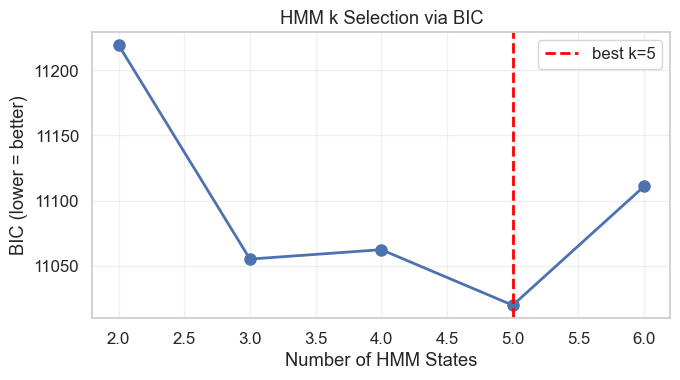

✓ Saved BIC plot


In [14]:
hmm_bics = {}
hmm_models = {}

for k in range(2, 7):
    bics_run = []
    for seed in [42, 7, 99]:
        m = GaussianHMM(n_states=k, n_iter=200, tol=1e-5, random_state=seed)
        m.fit(sequences_X)
        bics_run.append((m.bic(sequences_X), m))
    best_bic, best_m = min(bics_run, key=lambda x: x[0])
    hmm_bics[k] = best_bic
    hmm_models[k] = best_m
    print(f"  k={k}  BIC={best_bic:.1f}  logL={best_m.log_likelihood_:.1f}")

best_k_hmm = min(hmm_bics, key=hmm_bics.get)
print(f"\n🎯 Best k by BIC: {best_k_hmm}")

# Plot BIC curve
fig, ax = plt.subplots(figsize=(7, 4))
ks = sorted(hmm_bics.keys())
ax.plot(ks, [hmm_bics[k] for k in ks], 'o-', linewidth=2, markersize=8)
ax.axvline(best_k_hmm, ls='--', color='red', lw=2, label=f'best k={best_k_hmm}')
ax.set_xlabel('Number of HMM States'); ax.set_ylabel('BIC (lower = better)')
ax.set_title('HMM k Selection via BIC'); ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/hmm_bic_selection_updated_overlaps.png', dpi=300, bbox_inches='tight')
plt.show()

print(f'✓ Saved BIC plot')

## 6. Decode States & Assign to Data

In [15]:
best_hmm = hmm_models[best_k_hmm]
K_HMM = best_k_hmm

hmm_state_col = np.full(len(data_clean), -1, dtype=int)

for meta, seq in zip(sequences_meta, sequences_X):
    grp, task = meta['group_id'], meta['task_id']
    path = best_hmm.decode(seq)
    sub_idx = data_clean[(data_clean['group_id']==grp) & (data_clean['task_id']==task)].sort_values('window_index').index
    hmm_state_col[data_clean.index.get_indexer(sub_idx)] = path

data_clean['hmm_state'] = hmm_state_col
valid = data_clean['hmm_state'] >= 0

print(f'✓ Windows with HMM state assigned: {valid.sum()} / {len(data_clean)}')
print(f'\nState distribution:')
for state_id in range(K_HMM):
    count = (data_clean['hmm_state'] == state_id).sum()
    pct = count / valid.sum() * 100
    print(f'  State {state_id}: {count:3d} windows ({pct:5.1f}%)')

✓ Windows with HMM state assigned: 545 / 545

State distribution:
  State 0:  87 windows ( 16.0%)
  State 1:  92 windows ( 16.9%)
  State 2: 149 windows ( 27.3%)
  State 3:  92 windows ( 16.9%)
  State 4: 125 windows ( 22.9%)


## 7. State Profiles & Transitions

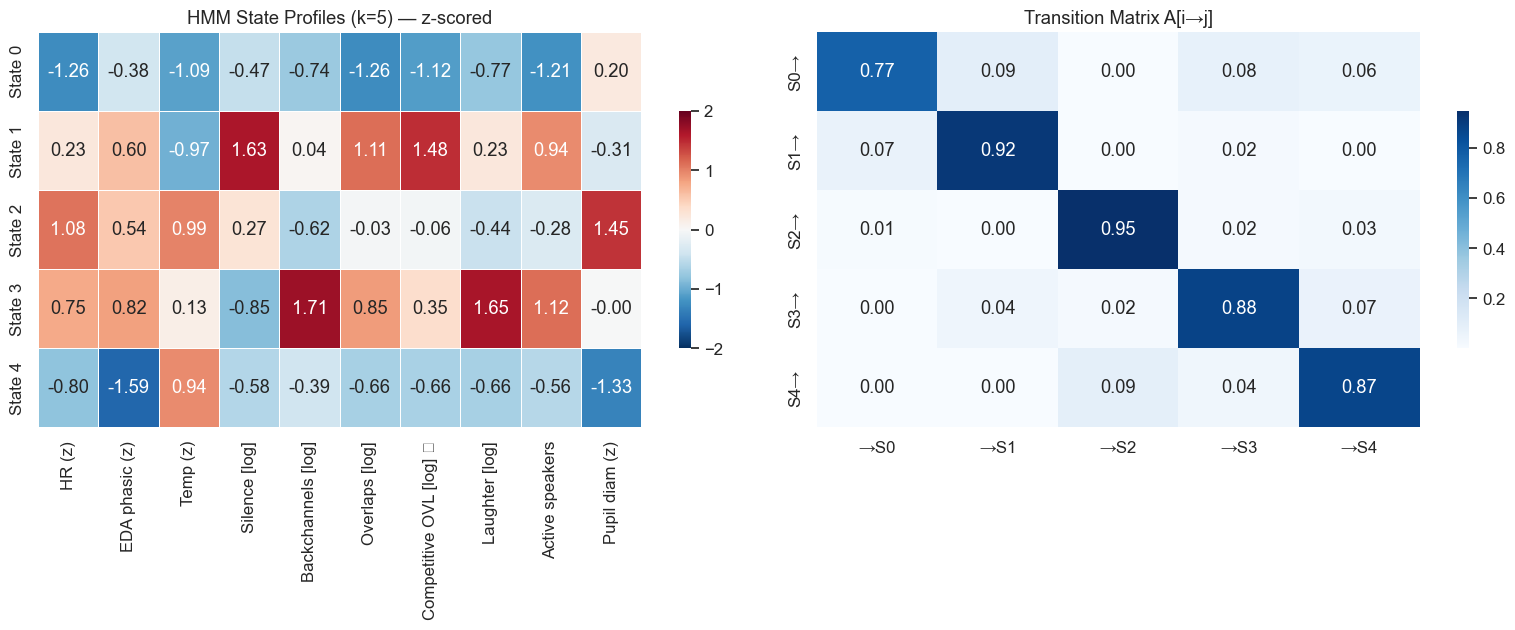

✓ Saved profile heatmap


In [16]:
dc_valid = data_clean[valid].copy()

prof_hmm = dc_valid.groupby('hmm_state')[CLEAN_FEATS].mean()
prof_hmm.index = [f'State {i}' for i in prof_hmm.index]
prof_hmm_z = (prof_hmm - prof_hmm.mean()) / (prof_hmm.std() + 1e-9)
prof_hmm_z.columns = CLEAN_LABELS

fig, axes = plt.subplots(1, 2, figsize=(16, K_HMM*0.9 + 2))

sns.heatmap(prof_hmm_z, cmap='RdBu_r', center=0, annot=True, fmt='.2f',
            linewidths=0.4, ax=axes[0], vmin=-2, vmax=2, cbar_kws={'shrink': 0.6})
axes[0].set_title(f'HMM State Profiles (k={K_HMM}) — z-scored')

A = best_hmm.A_
sns.heatmap(A, annot=True, fmt='.2f', cmap='Blues', ax=axes[1],
            xticklabels=[f'→S{k}' for k in range(K_HMM)],
            yticklabels=[f'S{k}→' for k in range(K_HMM)],
            cbar_kws={'shrink': 0.6})
axes[1].set_title('Transition Matrix A[i→j]')

plt.tight_layout()
plt.savefig('../figures/hmm_profiles_transitions_updated_overlaps.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved profile heatmap')

## 8. Key Change: Competitive Overlap by State

In [17]:
print("=" * 70)
print("KEY CHANGE: tr_competitive_overlap")
print("=" * 70)

# Back to original scale (undo log)
comp_ovl_orig = np.expm1(dc_valid['tr_competitive_overlap'].dropna())

print(f"\n📊 Updated tr_competitive_overlap (ORIGINAL SCALE) by state:")
for state_id in range(K_HMM):
    state_comp = dc_valid[dc_valid['hmm_state'] == state_id]['tr_competitive_overlap'].dropna()
    state_comp_orig = np.expm1(state_comp)
    print(f"  State {state_id}: mean={state_comp_orig.mean():.2f}, median={state_comp_orig.median():.1f}, n={len(state_comp)}")

print(f"\n✓ Includes 52 previously 'needs_review' overlaps + 95+ reclassified entries")

KEY CHANGE: tr_competitive_overlap

📊 Updated tr_competitive_overlap (ORIGINAL SCALE) by state:
  State 0: mean=0.02, median=0.0, n=87
  State 1: mean=1.15, median=1.0, n=92
  State 2: mean=0.43, median=0.0, n=149
  State 3: mean=0.59, median=0.0, n=92
  State 4: mean=0.18, median=0.0, n=125

✓ Includes 52 previously 'needs_review' overlaps + 95+ reclassified entries


## 9. Summary & Export

In [18]:
print("=" * 70)
print("HMM COLLECTIVE STATES — UPDATED OVERLAP LABELS")
print("=" * 70)

print(f"\n✅ DATA:")
print(f"   Windows: {len(data_clean)}")
print(f"   Valid (with HMM state): {valid.sum()}")
print(f"   Groups: {sorted(data_clean['group_id'].unique())}")
print(f"   Tasks: T1, T2, T3")

print(f"\n✅ PREPROCESSING:")
print(f"   Within-group z-scoring: ✓ (physio + pupil diam)")
print(f"   Log transform: ✓ (skewed counts)")
print(f"   Clean features: {len(CLEAN_FEATS)}")
print(f"   PCA components (80% variance): {n80}")
print(f"   Sequences: {len(sequences_X)}")

print(f"\n✅ HMM RESULTS:")
print(f"   Number of states: {K_HMM}")
print(f"   Selected via: BIC minimization")
print(f"   BIC value: {hmm_bics[K_HMM]:.1f}")
print(f"   Log-likelihood: {best_hmm.log_likelihood_:.1f}")

print(f"\n✅ KEY CHANGE:")
print(f"   tr_competitive_overlap now includes:")
print(f"   • 52 previously 'needs_review' entries")
print(f"   • 95+ 'collaborative' reclassified by duration")
print(f"   • Method: Timing-based (no semantic labeling)")

print(f"\n✅ OUTPUT:")
print(f"   Figure: ../figures/hmm_bic_selection_updated_overlaps.png")
print(f"   Figure: ../figures/hmm_profiles_transitions_updated_overlaps.png")

print(f"\n💾 Ready for comparison with paper draft!")

HMM COLLECTIVE STATES — UPDATED OVERLAP LABELS

✅ DATA:
   Windows: 545
   Valid (with HMM state): 545
   Groups: ['grp-07', 'grp-08', 'grp-09', 'grp-10', 'grp-11', 'grp-12', 'grp-13', 'grp-14', 'grp-15', 'grp-16']
   Tasks: T1, T2, T3

✅ PREPROCESSING:
   Within-group z-scoring: ✓ (physio + pupil diam)
   Log transform: ✓ (skewed counts)
   Clean features: 10
   PCA components (80% variance): 7
   Sequences: 28

✅ HMM RESULTS:
   Number of states: 5
   Selected via: BIC minimization
   BIC value: 11019.6
   Log-likelihood: -5197.9

✅ KEY CHANGE:
   tr_competitive_overlap now includes:
   • 52 previously 'needs_review' entries
   • 95+ 'collaborative' reclassified by duration
   • Method: Timing-based (no semantic labeling)

✅ OUTPUT:
   Figure: ../figures/hmm_bic_selection_updated_overlaps.png
   Figure: ../figures/hmm_profiles_transitions_updated_overlaps.png

💾 Ready for comparison with paper draft!


In [21]:
# Export cluster assignments for comparison
export = dc_valid[['group_id', 'task_id', 'hmm_state']].copy()
export.to_csv('../results/hmm_cluster_assignments_k5_updated_overlaps.tsv', sep='\t', index=False)
print(f"✓ Exported {len(export)} cluster assignments to TSV")
print(f"  Columns: {list(export.columns)}")
print(f"\nState distribution:")
print(export['hmm_state'].value_counts().sort_index())

✓ Exported 545 cluster assignments to TSV
  Columns: ['group_id', 'task_id', 'hmm_state']

State distribution:
hmm_state
0     87
1     92
2    149
3     92
4    125
Name: count, dtype: int64
